In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from core.dgp import IIDProcess, APDInnov, ARGARCHProcess, NormalInnov
from core.models import IIDNormalModel, IIDNonNormalModel, AR1NormalModel, AR1NonNormalModel, AvarModel

from core.bias_correction_comp import run_bias_comp

In [46]:
N    = 50_000
Ts = 15 + (300 - 15) * (np.linspace(0, 1, 80)**2) 
Ts = np.round(Ts).astype(int)
Ts = np.unique(Ts)
Ts   = [15, 30, 50, 100, 300]
dgp  = IIDProcess(APDInnov(alpha=0.7, lam=1.35)).calibrate_params(mu=0.5, sigma=1)
#dgp  = ARGARCHProcess().calibrate_params(mu=0.15, sigma=0.30)
models = [IIDNormalModel(), IIDNonNormalModel(), AR1NormalModel(), AR1NonNormalModel()]


estimate  corrected
model             T                       
AR1NonNormalModel 15   0.587001   0.506570
                  30   0.542144   0.494553
                  50   0.524536   0.493039
                  100  0.511980   0.494707
                  300  0.504128   0.497947
AR1NormalModel    15   0.587001   0.554503
                  30   0.542144   0.528009
                  50   0.524536   0.516471
                  100  0.511980   0.508092
                  300  0.504128   0.502862
IIDNonNormalModel 15   0.587001   0.539278
                  30   0.542144   0.512596
                  50   0.524536   0.504795
                  100  0.511980   0.501141
                  300  0.504128   0.500252
IIDNormalModel    15   0.587001   0.559049
                  30   0.542144   0.528921
                  50   0.524536   0.516784
                  100  0.511980   0.508169
                  300  0.504128   0.502871

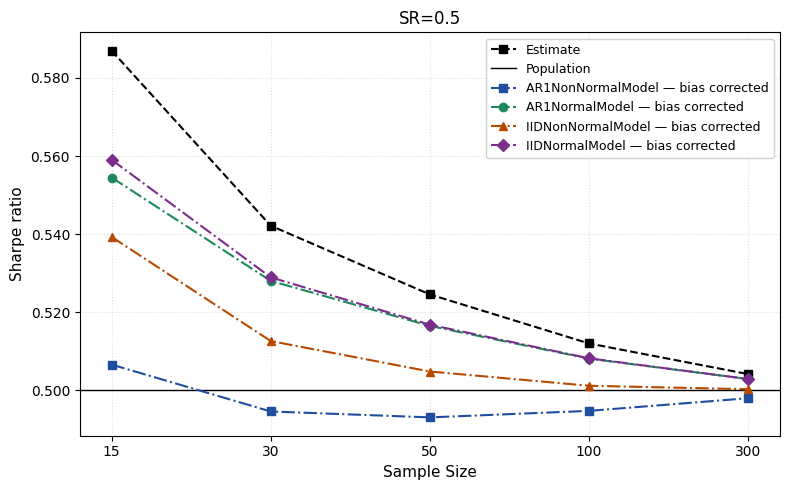

In [47]:
run_bias_comp(0.5, N, Ts, dgp, models)